# Credit Risk Scoring System

## Objective
The objective of this project is to predict whether a loan applicant is a good or bad credit risk based on financial and demographic information.

Dataset: German Credit Dataset

Problem Type: Binary Classification

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


In [3]:
from google.colab import files

uploaded = files.upload()

Saving german_credit_data.csv.xlsx to german_credit_data.csv.xlsx


In [4]:
df = pd.read_excel("german_credit_data.csv.xlsx")

df.head()

,checking account,duration,credit history,purpose,credit amount,savings account,employment duration,installment rate,personal status,guarantor,...,property,age,other installments,housing,existing credits,job,dependents,telephone,foreign worker,credit risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   checking account     1000 non-null   int64
 1   duration             1000 non-null   int64
 2   credit history       1000 non-null   int64
 3   purpose              1000 non-null   int64
 4   credit amount        1000 non-null   int64
 5   savings account      1000 non-null   int64
 6   employment duration  1000 non-null   int64
 7   installment rate     1000 non-null   int64
 8   personal status      1000 non-null   int64
 9   guarantor            1000 non-null   int64
 10  residence duration   1000 non-null   int64
 11  property             1000 non-null   int64
 12  age                  1000 non-null   int64
 13  other installments   1000 non-null   int64
 14  housing              1000 non-null   int64
 15  existing credits     1000 non-null   int64
 16  job                  1000

In [6]:
df.columns

Index(['checking account', 'duration', 'credit history', 'purpose',
       'credit amount', 'savings account', 'employment duration',
       'installment rate', 'personal status', 'guarantor',
       'residence duration', 'property', 'age', 'other installments',
       'housing', 'existing credits', 'job', 'dependents', 'telephone',
       'foreign worker', 'credit risk'],
      dtype='object')

In [7]:
df['credit risk'].value_counts()

,count
credit risk,
1,700
0,300


In [8]:
df.rename(columns={'credit risk':'risk'}, inplace=True)

df.head()

,checking account,duration,credit history,purpose,credit amount,savings account,employment duration,installment rate,personal status,guarantor,...,property,age,other installments,housing,existing credits,job,dependents,telephone,foreign worker,risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [9]:
X = df.drop('risk', axis=1)

y = df['risk']

In [10]:
print(X.shape)
print(y.shape)


(1000, 20)
(1000,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
print(X_train.shape)
print(X_test.shape)

(800, 20)
(200, 20)


In [13]:
df['risk'].value_counts()

,count
risk,
1,700
0,300


In [14]:
df['risk'].value_counts(normalize=True) * 100

,proportion
risk,
1,70.0
0,30.0


The dataset is slightly imbalanced, with one class appearing more frequently than the other.


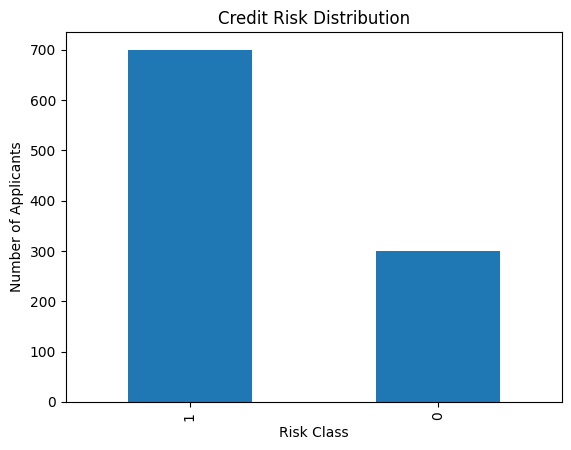

In [15]:
df['risk'].value_counts().plot(kind='bar')

plt.title('Credit Risk Distribution')
plt.xlabel('Risk Class')
plt.ylabel('Number of Applicants')
plt.show()

In [16]:
df['credit amount'].describe()

,credit amount
count,1000.00000
mean,3271.24800
std,2822.75176
min,250.00000
25%,1365.50000
50%,2319.50000
75%,3972.25000
max,18424.00000


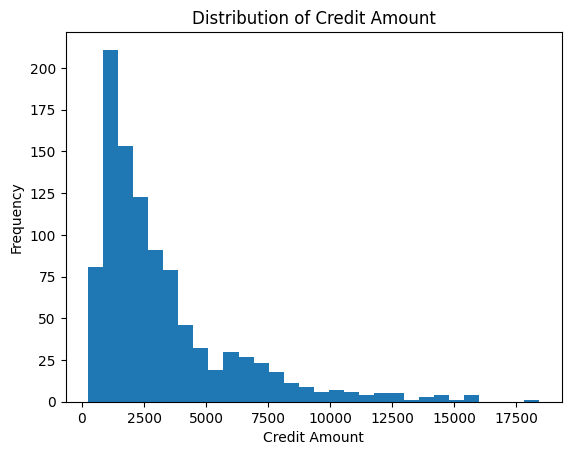

In [17]:
df['credit amount'].plot(kind='hist', bins=30)

plt.title('Distribution of Credit Amount')
plt.xlabel('Credit Amount')
plt.ylabel('Frequency')
plt.show()


In [18]:
df['age'].describe()

,age
count,1000.00000
mean,35.54200
std,11.35267
min,19.00000
25%,27.00000
50%,33.00000
75%,42.00000
max,75.00000


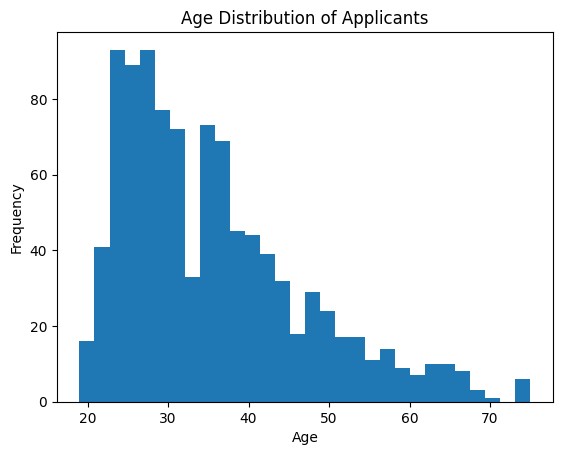

In [19]:
df['age'].plot(kind='hist', bins=30)

plt.title('Age Distribution of Applicants')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [20]:
df.groupby('risk')['credit amount'].mean()

,credit amount
risk,
0,3938.126667
1,2985.442857


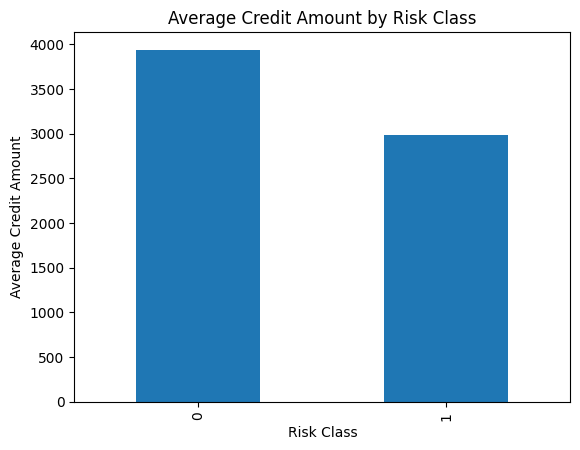

In [21]:
df.groupby('risk')['credit amount'].mean().plot(kind='bar')

plt.title('Average Credit Amount by Risk Class')
plt.xlabel('Risk Class')
plt.ylabel('Average Credit Amount')
plt.show()

In [22]:
df.groupby('risk')['duration'].mean()

,duration
risk,
0,24.860000
1,19.207143


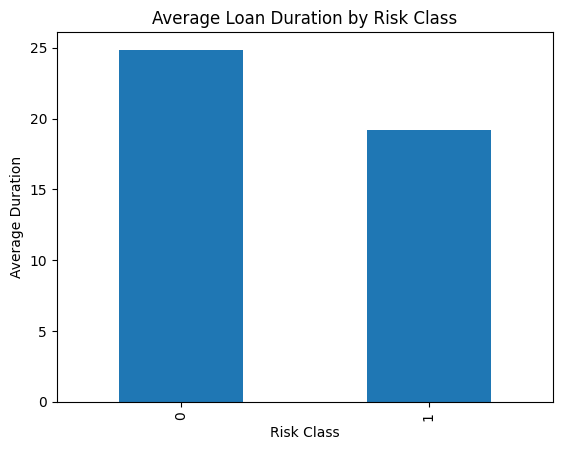

In [23]:
df.groupby('risk')['duration'].mean().plot(kind='bar')

plt.title('Average Loan Duration by Risk Class')
plt.xlabel('Risk Class')
plt.ylabel('Average Duration')
plt.show()

In [24]:
corr = df.corr()

corr['risk'].sort_values(ascending=False)

,risk
risk,1.000000
checking account,0.350847
credit history,0.228785
savings account,0.178943
employment duration,0.116002
other installments,0.109844
age,0.091272
personal status,0.088184
existing credits,0.045732
telephone,0.036466


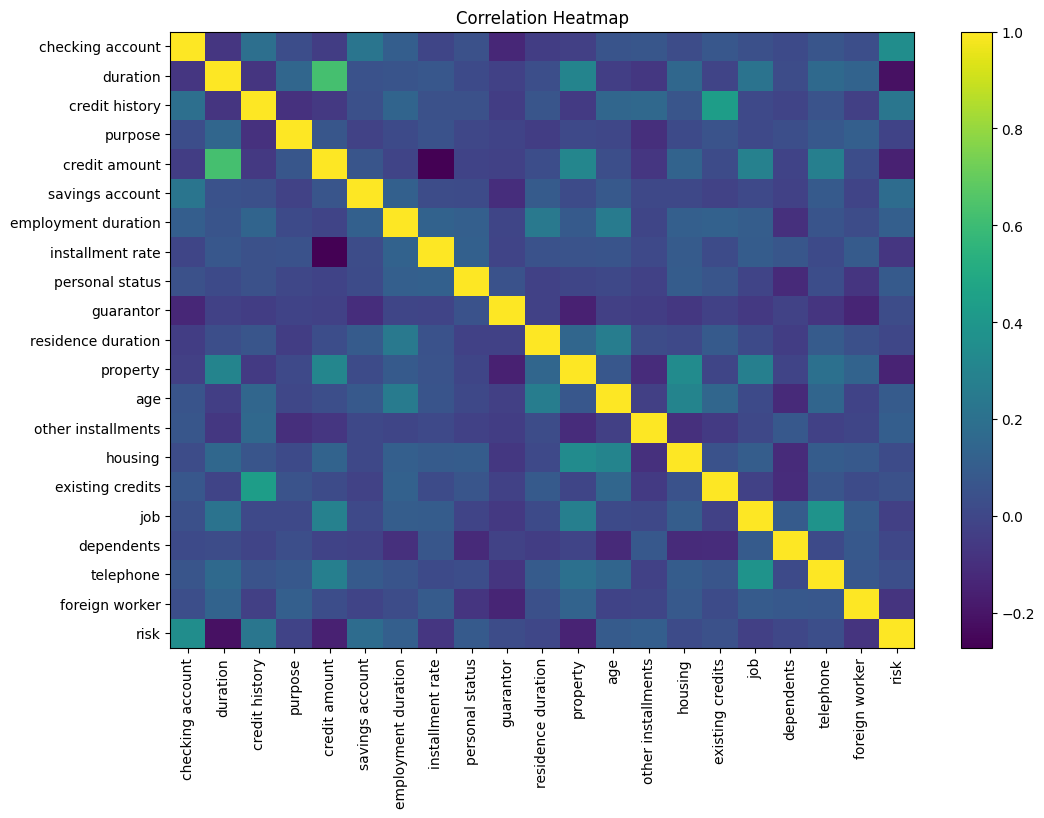

In [25]:
plt.figure(figsize=(12, 8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()


## EDA Findings

- The dataset contains 1000 loan applicants.
- The target variable is moderately imbalanced.
- Applicants in risk class 0 have a higher average credit amount than class 1.
- Applicants in risk class 0 also have longer average loan durations.
- Checking account status shows the strongest relationship with credit risk.
- Credit history and savings account status also appear important for risk prediction.
- Multiple variables are likely required to accurately assess creditworthiness.

In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [29]:
y_pred = model.predict(X_test_scaled)

In [30]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.75


In [31]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[ 27  35]
 [ 15 123]]


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.44      0.52        62
           1       0.78      0.89      0.83       138

    accuracy                           0.75       200
   macro avg       0.71      0.66      0.68       200
weighted avg       0.74      0.75      0.73       200



## Logistic Regression Results

- Logistic Regression achieved an accuracy of 75% on the test dataset.
- The model performed strongly on Class 1 with a recall of 89%.
- Performance on Class 0 was weaker with a recall of 44%.
- The difference is likely due to class imbalance in the dataset.
- Overall, the model demonstrates reasonable predictive capability for credit risk assessment.

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.735


In [35]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, rf_pred))

[[ 26  36]
 [ 17 121]]


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.60      0.42      0.50        62
           1       0.77      0.88      0.82       138

    accuracy                           0.73       200
   macro avg       0.69      0.65      0.66       200
weighted avg       0.72      0.73      0.72       200



The Random Forest model achieved an accuracy of 73.5%, slightly lower than the Logistic Regression model (75%).

Although Random Forest is a more complex model, Logistic Regression performed better on this dataset, suggesting that the relationship between applicant attributes and credit risk is relatively linear.

Therefore, Logistic Regression was selected as the preferred model for this project.

In [37]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
4,credit amount,0.138115
0,checking account,0.106259
1,duration,0.106220
12,age,0.101204
2,credit history,0.063278
3,purpose,0.061785
5,savings account,0.049881
6,employment duration,0.049045
11,property,0.042358
7,installment rate,0.041511


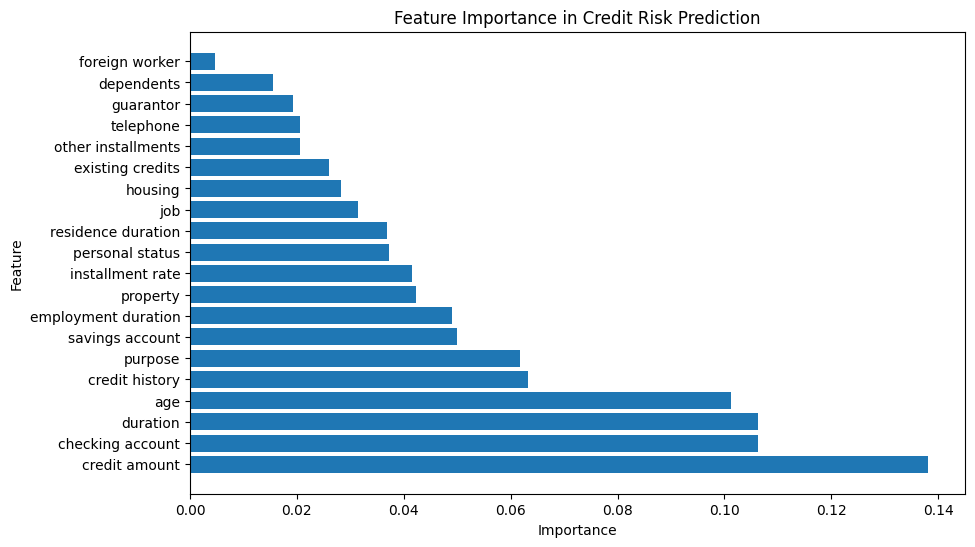

In [38]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in Credit Risk Prediction")

plt.show()

## Feature Importance Analysis

The Random Forest model identified Credit Amount, Checking Account Status, Duration, Age, and Credit History as the most influential factors in credit risk prediction.

Credit Amount emerged as the strongest predictor, indicating that loan size plays a significant role in assessing risk. Checking Account Status and Credit History were also important, reflecting the importance of financial stability and previous repayment behavior.

These findings align with real-world banking practices, where lenders evaluate applicant financial profiles, repayment history, and loan characteristics before making lending decisions.

# Final Business Insights

1. Logistic Regression achieved an accuracy of 75%, outperforming Random Forest (73.5%) on this dataset.

2. The model was significantly better at identifying Class 1 applicants than Class 0 applicants, likely due to class imbalance in the dataset.

3. Credit Amount, Checking Account Status, Duration, Age, and Credit History were identified as the most influential variables affecting credit risk.

4. No single variable was sufficient to predict risk accurately. The model relied on multiple financial and demographic factors simultaneously.

5. The project demonstrates how machine learning can support credit risk assessment and lending decisions in financial institutions.